### We wish to run simulations to explore how 'phylogenetic importance' and 'functional importance' emerge as predictions from conservation. 

General approach:

Take a single length $L$ sequence. Compute fitness according to:
$$
\mathcal{F}(S) = f\bigg(\sum_{j=1}^L\sum_{a =1}^{20} \beta_j^a \delta(s_j,  a)\bigg).
$$
Hence, fitness is a sum of the fitness at each residue, and each amino acid has a residue-dependent fitness. However, many residues are unimportant, and hence $\beta_j = 0$, there is no fitness contribution. Otherwise, $\beta \in \mathbb{R}^{Lx20}$ is a matrix describing the fitness contribution of having any given amino acid at any given residue. $f$ is a sigmoid function, $f = 1/(1 + e^{-x/T})$.

Let's make some basic assumptions to let us simulate. Say that half of residues are unimportant, meaning the columns $\beta_j = 0$. For each important residue, the value $\beta_j^a$ can be drawn from a normal distribution, $\beta_j^a \sim \mathcal{N}(0, 1)$. 

After, $\beta$ is constructed, evolve the system. At each timestep, $S_i$ has a probability of replicating prortional to $\mathcal{F}(S_i)$. When it replicates, each residue has a small probability of mutating, $\mu$. 

Iterate the system forward until you reach a target number of sequences, $M$. When iterating, track phylogeny.

Begin by constructing a matrix, $\beta$. 

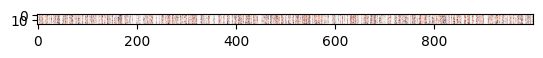

In [106]:
import numpy as np
import matplotlib.pyplot as plt 

L = 1000 #Sequence Length

importance = np.zeros(L)
for i in range(len(importance)):
    importance[i] = np.random.binomial(n = 1, p = 0.5)
    
beta = np.zeros((20,L))
for a in range(20):
    for s in range(L):
        if importance[s] == 1:
            if np.random.binomial(n = 1, p = 0.8) == 1:
                beta[a, s] = np.random.normal(-1, 0.5)
            else:
                beta[a, s] = np.random.normal(5,2) #this way, expected fitness starts out at 0.5
            
plt.imshow(beta, cmap = 'RdBu', vmax = 3)

In [108]:

class EvolvingSequence:
    """
    A sequence that tracks its evolutionary history
    """
    # Class variable to track all sequences and assign unique IDs
    _next_id = 0
    all_sequences = {}  # id -> EvolvingSequence object
    
    def __init__(self, sequence, parent=None, birth_time=0):
        self.sequence = np.array(sequence)  # your array of numbers 1-20
        self.parent = parent                # reference to parent sequence
        self.birth_time = birth_time        # when this sequence was born
        self.children = []                  # track children for full phylogeny
        self.id = EvolvingSequence._next_id
        EvolvingSequence._next_id += 1
        self.alive = True  # Track if sequence is still in population
        
        # Store in global registry
        EvolvingSequence.all_sequences[self.id] = self
    
    def replicate(self, mutated_sequence, current_time):
        """Create a child sequence with mutation"""
        child = EvolvingSequence(mutated_sequence, parent=self, birth_time=current_time)
        self.children.append(child)
        return child
    
    def get_fitness(self):
        """Calculate fitness using your fitness function"""
        return fitness(self.sequence)
    
    def mutate_and_replicate(self, current_time):
        """Convenience method: mutate this sequence and create child"""
        mutated_seq = mutate(self.sequence.copy())  # Important: copy the array!
        return self.replicate(mutated_seq, current_time)
    
    def get_lineage(self):
        """Get the entire ancestry back to root"""
        lineage = []
        current = self
        while current is not None:
            lineage.append(current)
            current = current.parent
        return lineage[::-1]  # Return from oldest to newest
    
    def find_common_ancestor(self, other):
        """Find the most recent common ancestor with another sequence"""
        # Get both lineages
        my_lineage = {seq.id for seq in self.get_lineage()}
        
        current = other
        while current is not None:
            if current.id in my_lineage:
                return current
            current = current.parent
        return None  # Should only happen if they have different roots

# Fitness and mutation functions
T = 0.5*L/2 #scale this
def fitness(S):
    """Assuming S is a length L sequence of amino acids."""
    temp = 0
    for i in range(L):
        temp += beta[S[i]-1, i]  # Note: -1 if beta is 0-indexed
    return 1 / (1 + np.exp(-temp / T))

mu = 1/L  # Expected mutations per sequence
def mutate(S):
    """Mutate a sequence in-place"""
    for i in range(L):
        if np.random.binomial(n=1, p=mu) == 1:
            S[i] = np.random.randint(1, 21)
    return S

def run_evolution_with_epochs(initial_sequence, target_population_size, num_epochs, generations_per_epoch, death_scaling=0.5, replicate_scaling=0.5):
    """
    Run evolution with multiple epochs and population bottlenecks
    """
    # Initialize with first sequence
    root_sequence = EvolvingSequence(initial_sequence, parent=None, birth_time=0)
    population = [root_sequence]
    
    total_generations = 0
    
    for epoch in range(num_epochs):
        print(f"\n=== Epoch {epoch + 1}/{num_epochs} ===")
        
        # Phase 1: Grow and evolve population for several generations
        for generation in range(1, generations_per_epoch + 1):
            total_generations += 1
            new_children = []
            dead_sequences = []
            
            # Each sequence may replicate OR die
            for seq in population:
                f = seq.get_fitness()
                
                # Replication probability = fitness
                if np.random.random() < replicate_scaling*f:
                    child = seq.mutate_and_replicate(current_time=total_generations)
                    new_children.append(child)
                
                # Death probability
                death_prob = (1 - f) * death_scaling
                if np.random.random() < death_prob:
                    dead_sequences.append(seq)
                    seq.alive = False
            
            # Update population
            population = [seq for seq in population if seq not in dead_sequences]
            population.extend(new_children)
            
            # Emergency check: if population is extinct, raise exception
            if len(population) == 0:
                raise ExtinctionException(f"Population went extinct at generation {total_generations}")
            
            # Control population growth during epoch
            if len(population) > target_population_size * 2:
                # Randomly sample to control explosive growth
                indices = np.random.choice(len(population), size=target_population_size, replace=False)
                population = [population[i] for i in indices]
        
        print(f"Pre-bottleneck: {len(population)} sequences")
        
        # Phase 2: Bottleneck - probabilistic death based on fitness
        survivors = []
        for seq in population:
            f = seq.get_fitness()
            
            # Death probability increases as fitness decreases
            # We want ~90% to die, so scale the death probability
            death_prob = (1 - f) * 2  # Adjust this scaling factor to get ~90% death rate
            
            # Cap death probability at 9% to ensure some survival
            death_prob = min(death_prob, 0.9)
            death_prob = max(death_prob, 0.1) #death probability is atleast 10%
            
            if np.random.random() > death_prob:  # Survival = 1 - death_prob
                survivors.append(seq)
            else:
                seq.alive = False

        population = survivors

        # Emergency check: if no survivors after bottleneck
        if len(population) == 0:
            raise ExtinctionException(f"All sequences died in bottleneck at epoch {epoch + 1}")

        print(f"Post-bottleneck: {len(population)} survivors")
        
        # Phase 3: Regrowth - survivors repopulate back to target size
        while len(population) < target_population_size:
            parent = np.random.choice(survivors)
            child = parent.mutate_and_replicate(current_time=total_generations)
            population.append(child)
        
        # Final population control
        if len(population) > target_population_size:
            population = population[:target_population_size]
        
        # Epoch statistics
        epoch_fitness = np.mean([seq.get_fitness() for seq in population])
        print(f"Epoch {epoch + 1} complete: {len(population)} sequences, avg fitness = {epoch_fitness:.3f}")
    
    return population

class ExtinctionException(Exception):
    """Custom exception for population extinction"""
    pass

def run_simulation_with_retry(max_attempts=10):
    """
    Run the simulation with automatic retry if population goes extinct
    """
    for attempt in range(max_attempts):
        try:
            # Reset the sequence counter for each attempt
            EvolvingSequence._next_id = 0
            EvolvingSequence.all_sequences.clear()
            
            print(f"\n{'='*50}")
            print(f"Simulation Attempt {attempt + 1}/{max_attempts}")
            print(f"{'='*50}")
            
            # Create new initial sequence for each attempt
            initial_seq = np.random.randint(1, 21, size=L)
            print(f"New initial sequence fitness: {fitness(initial_seq):.3f}")
            
            # Run simulation
            final_population = run_evolution_with_epochs(
                initial_sequence=initial_seq,
                target_population_size=M,
                num_epochs=K,
                generations_per_epoch=generations_per_epoch,
                death_scaling=0.3,
                replicate_scaling=1
            )
            
            # If we get here, simulation succeeded!
            print(f"\n{'='*50}")
            print("SIMULATION SUCCEEDED!")
            print(f"{'='*50}")
            print(f"Final population size: {len(final_population)}")
            print(f"Total sequences created: {EvolvingSequence._next_id}")
            
            # Analyze final population
            fitness_values = [seq.get_fitness() for seq in final_population]
            print(f"Average fitness: {np.mean(fitness_values):.3f}")
            print(f"Fitness range: {np.min(fitness_values):.3f} - {np.max(fitness_values):.3f}")
            
            return final_population
            
        except ExtinctionException as e:
            print(f"❌ Attempt {attempt + 1} failed: {e}")
            print("Retrying with new initial sequence...")
            
            # Optional: adjust parameters if we keep failing
            if attempt >= 3:
                print("Multiple failures detected. You might want to adjust death_scaling or replicate_scaling.")
            
        except Exception as e:
            print(f"❌ Unexpected error in attempt {attempt + 1}: {e}")
            print("Retrying...")
    
    # If all attempts fail
    print(f"\n💀 ALL {max_attempts} ATTEMPTS FAILED!")
    print("Try adjusting these parameters:")
    print("  - Increase replicate_scaling (currently 0.5)")
    print("  - Decrease death_scaling (currently 0.5)")
    print("  - Decrease bottleneck severity (death_prob scaling)")
    return None

# Simulation parameters
L = 1000  # sequence length
M = 1000  # target population size
K = 100     # number of epochs
generations_per_epoch = 20  # generations between bottlenecks

print("Starting evolution simulation with epochs and automatic retry...")
print(f"Target population: {M}, Epochs: {K}, Generations per epoch: {generations_per_epoch}")
print(f"Max beta value: {np.max(beta):.3f}")

# Run simulation with automatic retry
final_population = run_simulation_with_retry(max_attempts=100)

if final_population is not None:
    print(f"\n🎉 Simulation completed successfully!")
else:
    print(f"\n😞 Simulation failed after all retry attempts.")

Starting evolution simulation with epochs and automatic retry...
Target population: 1000, Epochs: 100, Generations per epoch: 20
Max beta value: 11.995

Simulation Attempt 1/100
New initial sequence fitness: 0.628

=== Epoch 1/100 ===
Pre-bottleneck: 1897 sequences
Post-bottleneck: 520 survivors
Epoch 1 complete: 1000 sequences, avg fitness = 0.627

=== Epoch 2/100 ===
Pre-bottleneck: 1000 sequences
Post-bottleneck: 259 survivors
Epoch 2 complete: 1000 sequences, avg fitness = 0.632

=== Epoch 3/100 ===
Pre-bottleneck: 1000 sequences
Post-bottleneck: 277 survivors
Epoch 3 complete: 1000 sequences, avg fitness = 0.636

=== Epoch 4/100 ===
Pre-bottleneck: 1000 sequences
Post-bottleneck: 282 survivors
Epoch 4 complete: 1000 sequences, avg fitness = 0.637

=== Epoch 5/100 ===
Pre-bottleneck: 1000 sequences
Post-bottleneck: 243 survivors
Epoch 5 complete: 1000 sequences, avg fitness = 0.640

=== Epoch 6/100 ===
Pre-bottleneck: 1000 sequences
Post-bottleneck: 287 survivors
Epoch 6 complete: 

In [109]:
def analyze_phylogeny(population):
    """Analyze relationships in the final population"""
    print("\n=== PHYLOGENY ANALYSIS ===")
    
    # Build relatedness matrix
    n = len(population)
    relatedness = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            mrca = population[i].find_common_ancestor(population[j])
            if mrca:
                # Relatedness = how recently they diverged (higher = more recent)
                relatedness[i,j] = mrca.birth_time
                relatedness[j,i] = mrca.birth_time
    
    print("Relatedness matrix (divergence time of MRCA):")
    print(relatedness)
    
    # Find closest relatives
    max_relatedness = 0
    closest_pair = (0, 1)
    for i in range(n):
        for j in range(i+1, n):
            if relatedness[i,j] > max_relatedness:
                max_relatedness = relatedness[i,j]
                closest_pair = (i, j)
    
    print(f"\nMost closely related pair: sequences {closest_pair[0]} and {closest_pair[1]}")
    print(f"They diverged at generation {max_relatedness}")
    
    return relatedness

# After simulation:
relatedness_matrix = analyze_phylogeny(final_population)


=== PHYLOGENY ANALYSIS ===
Relatedness matrix (divergence time of MRCA):
[[   0. 1115. 1115. ... 1115. 1115. 1115.]
 [1115.    0. 1933. ... 1900. 1831. 1405.]
 [1115. 1933.    0. ... 1900. 1831. 1405.]
 ...
 [1115. 1900. 1900. ...    0. 1831. 1405.]
 [1115. 1831. 1831. ... 1831.    0. 1405.]
 [1115. 1405. 1405. ... 1405. 1405.    0.]]

Most closely related pair: sequences 20 and 903
They diverged at generation 2000.0


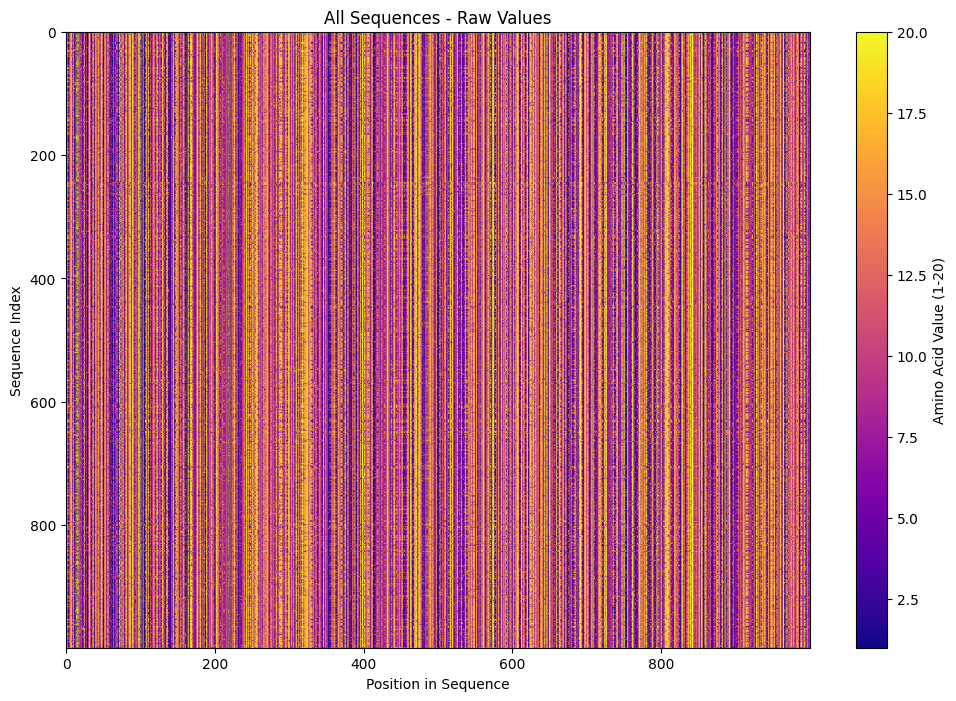

In [110]:

sequence_matrix = np.array([seq.sequence for seq in final_population])

plt.figure(figsize=(12, 8))
plt.imshow(sequence_matrix, cmap='plasma', aspect='auto')
plt.colorbar(label='Amino Acid Value (1-20)')
plt.xlabel('Position in Sequence')
plt.ylabel('Sequence Index')
plt.title('All Sequences - Raw Values')
plt.show()


# plt.imshow(relatedness_matrix)
# plt.colorbar()

/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_63294/4060280382.py:14: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(alignment_matrix, method='ward', metric='euclidean')


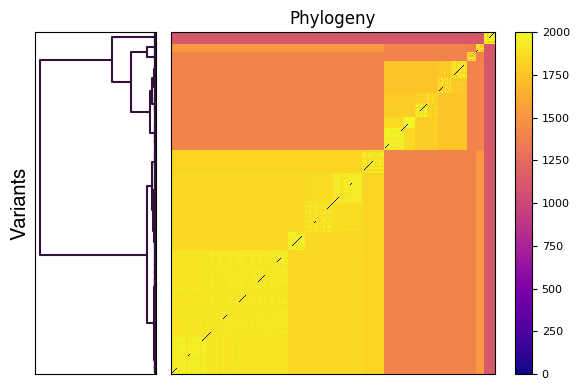

In [114]:

import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib.colors import ListedColormap

alignment_matrix = relatedness_matrix

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4), gridspec_kw={'width_ratios': [0.3, 1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]


im = ax2.imshow(rearranged_data, aspect='auto', cmap='plasma',
                interpolation='nearest', origin='lower')

cbar = fig.colorbar(im, ax=ax2)



cbar.ax.tick_params(labelsize=8)

boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Phylogeny')



plt.tight_layout()

    
plt.show()
    

In [111]:
def compute_kl(sequence_matrix):
    """
    Manual KL divergence calculation
    """
    L = sequence_matrix.shape[1]
    kl_divergences = np.zeros(L)
    n_sequences = sequence_matrix.shape[0]
    
    # Uniform probability
    uniform_prob = 1.0 / 20
    
    for pos in range(L):
        # Count each amino acid (1-20)
        counts = np.zeros(20)
        for aa in range(1, 21):
            counts[aa-1] = np.sum(sequence_matrix[:, pos] == aa)
        
        # Convert to probabilities
        probs = counts / n_sequences
        
        # Compute KL divergence manually
        kl = 0
        for i in range(20):
            if probs[i] > 0:  # Only add if p_i > 0 (0 * log(0) = 0 by convention)
                kl += probs[i] * np.log(probs[i] / uniform_prob)
        
        kl_divergences[pos] = kl
    
    return kl_divergences


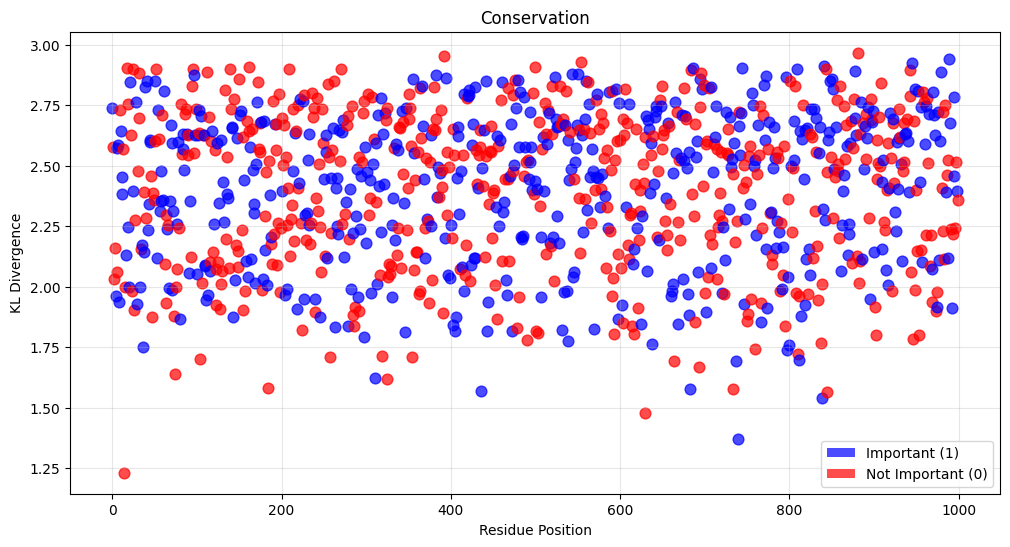

Mean Conserved KL 2.4041740551735833
Mean Variable KL 2.3946946701231933


In [112]:
kl_divergences = compute_kl(sequence_matrix)

# Plot as scatter plot
L = len(kl_divergences)

# Create colors array based on importance
colors = ['blue' if imp == 1 else 'red' for imp in importance]

plt.figure(figsize=(12, 6))

# Create scatter plot
for i in range(L):
    plt.scatter(i, kl_divergences[i], color=colors[i], alpha=0.7, s=60)

plt.xlabel('Residue Position')
plt.ylabel('KL Divergence')
plt.title('Conservation')
plt.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.7, label='Important (1)'),
    Patch(facecolor='red', alpha=0.7, label='Not Important (0)')
]
plt.legend(handles=legend_elements)

plt.show()

print('Mean Conserved KL', np.mean(kl_divergences[np.where(importance == 1)]))
print('Mean Variable KL', np.mean(kl_divergences[np.where(importance == 0)]))

### Next, run the experiement on the sequnces. 

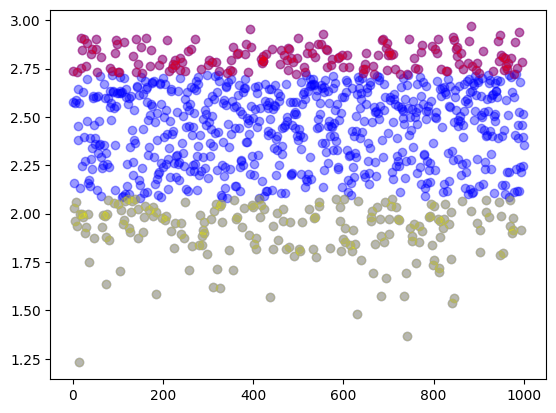

In [113]:
conservation = kl_divergences
x = np.linspace(1,len(conservation), len(conservation))
plt.scatter(x, conservation, color = 'Blue', alpha = 0.4)
consv_ind = np.where(conservation > np.mean(conservation) + np.std(conservation))
varia_ind = np.where(conservation < np.mean(conservation) - np.std(conservation))
plt.scatter(x[consv_ind], conservation[consv_ind], color = 'Red', alpha = 0.3)
plt.scatter(x[varia_ind], conservation[varia_ind], color = 'Yellow', alpha = 0.3)
plt.show()
# print(consv_ind[0])
varia_ind = varia_ind[0]
consv_ind = consv_ind[0]
